In [1]:
%matplotlib widget
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from TopNMF import *

2025-12-08 02:07:59.300649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765127279.311861  106329 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765127279.315350  106329 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-08 02:07:59.327286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
np.random.seed(42)
t = create_time_array(start=0, stop=2 * np.pi, n_points=100)
signals_dict_1 = generate_signals(t)
signals_dict_1 = normalize_signals(signals_dict_1, method="max")

X_list = [sig for sig in signals_dict_1.values()]
X = np.vstack(X_list)

signals_dict_2 = generate_signals(t, kind="triangle")
signals_dict_2 = normalize_signals(signals_dict_2, method="max")

Y_list = [sig for sig in signals_dict_2.values()]
Y = np.vstack(Y_list)

print(f"Generated {len(X_list)} signals with shape {X.shape}")
print(f"Generated {len(Y_list)} signals with shape {Y.shape}")

Generated 2 signals with shape (2, 100)
Generated 2 signals with shape (2, 100)


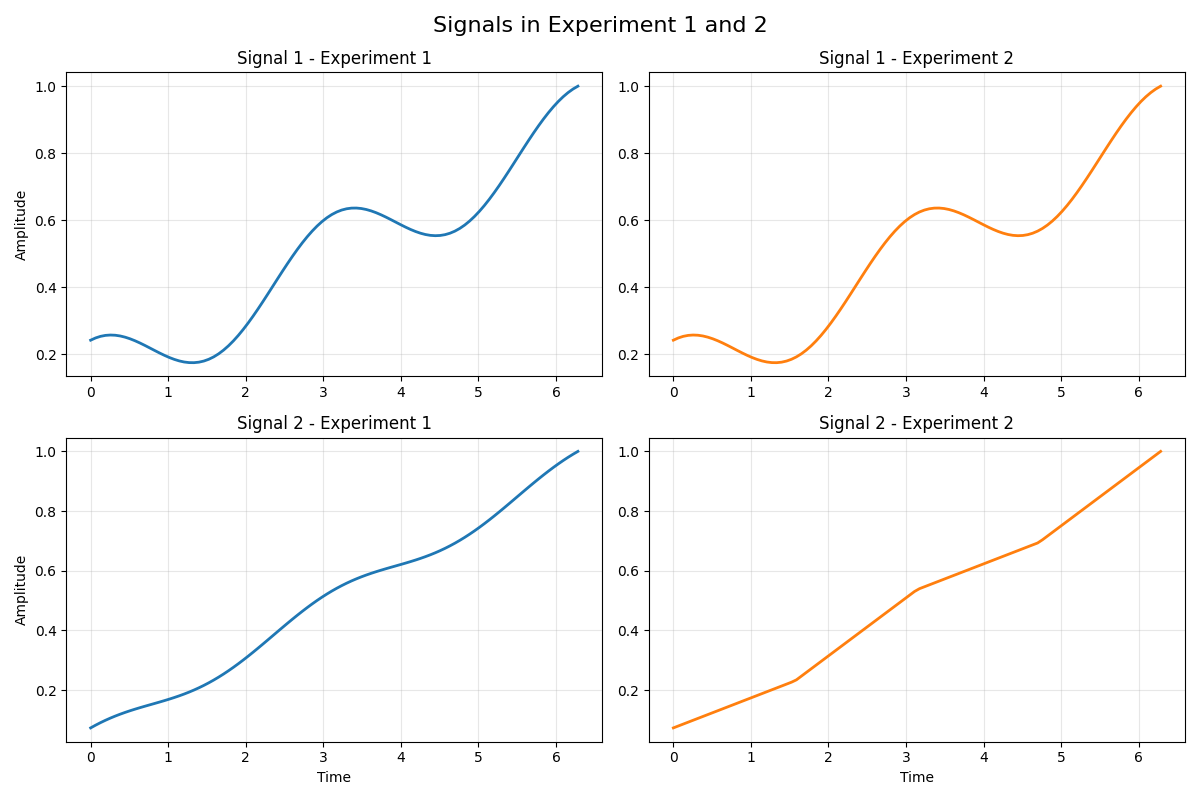

In [3]:
# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Set overall title
fig.suptitle("Signals in Experiment 1 and 2", fontsize=16)

# --- First Column: Experiment 1 (Cosine Data) ---
# Basis 1
axes[0, 0].plot(t, X[0], linewidth=2, color='tab:blue')
axes[0, 0].set_title("Signal 1 - Experiment 1")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylabel("Amplitude")

# Basis 2
axes[1, 0].plot(t, X[1], linewidth=2, color='tab:blue')
axes[1, 0].set_title("Signal 2 - Experiment 1")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].set_xlabel("Time")

# --- Second Column: Experiment 2 (Triangle Data) ---
# Basis 1
axes[0, 1].plot(t, Y[0], linewidth=2, color='tab:orange')
axes[0, 1].set_title("Signal 1 - Experiment 2")
axes[0, 1].grid(alpha=0.3)

# Basis 2
axes[1, 1].plot(t, Y[1], linewidth=2, color='tab:orange')
axes[1, 1].set_title("Signal 2 - Experiment 2")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlabel("Time")

plt.tight_layout()
plt.show()

## 2. Fit Topological NMF Model
We instantiate TopologicalNMF with two components and train it with a small topological loss weight.

In [4]:
n_components = 2
model_1 = TopologicalNMF(
    n_components=n_components,
    device="cpu",
    random_state=42
)

model_2 = TopologicalNMF(
    n_components=n_components,
    device="cpu",
    random_state=42
)

model_1.fit(
    X,
    n_iterations=10000,
    lr=0.005,
    lambda_apx=1.0,
    lambda_top=0.001,
    lambda_spa_V=0.0,
    lambda_spa_W=0.0,
    lambda_tv=0.0,
    target_periodicity=[1.0, 0.0],
    M=4,
    init_method="nndsvda",
    verbose=True
)

model_2.fit(
    Y,
    n_iterations=10000,
    lr=0.005,
    lambda_apx=1.0,
    lambda_top=0.001,
    lambda_spa_V=0.0,
    lambda_spa_W=0.0,
    lambda_tv=0.0,
    target_periodicity=[1.0, 0.0],
    M=4,
    init_method="nndsvda",
    verbose=True
)

print("Model fitted successfully!")

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Model fitted successfully!


## Visualize Results
The following cells inspect the learned basis signals and reconstructions.

In [5]:
V1 = model_1.get_components()
W1 = model_1.transform(X)
X_reconstructed_1 = model_1.inverse_transform()


V2 = model_2.get_components()
W2 = model_2.transform(Y)
X_reconstructed_2 = model_2.inverse_transform()

print(f"Components shape: {V1.shape}")
print(f"Coefficient matrix shape: {W1.shape}")
print(f"Components shape: {V2.shape}")
print(f"Coefficient matrix shape: {W2.shape}")

M = 4
tau = int(len(t) / (2 * (M + 1)))
for i in range(n_components):
    score = compute_periodicity_score(V1[i], dim=M + 1, tau=tau)
    print(f"Basis {i + 1} persistence score: {score:.4f}")
    score = compute_periodicity_score(V2[i], dim=M + 1, tau=tau)
    print(f"Basis {i + 1} persistence score: {score:.4f}")

Components shape: (2, 100)
Coefficient matrix shape: (2, 2)
Components shape: (2, 100)
Coefficient matrix shape: (2, 2)
Basis 1 persistence score: 0.9195
Basis 1 persistence score: 0.9160
Basis 2 persistence score: 0.0008
Basis 2 persistence score: 0.0156


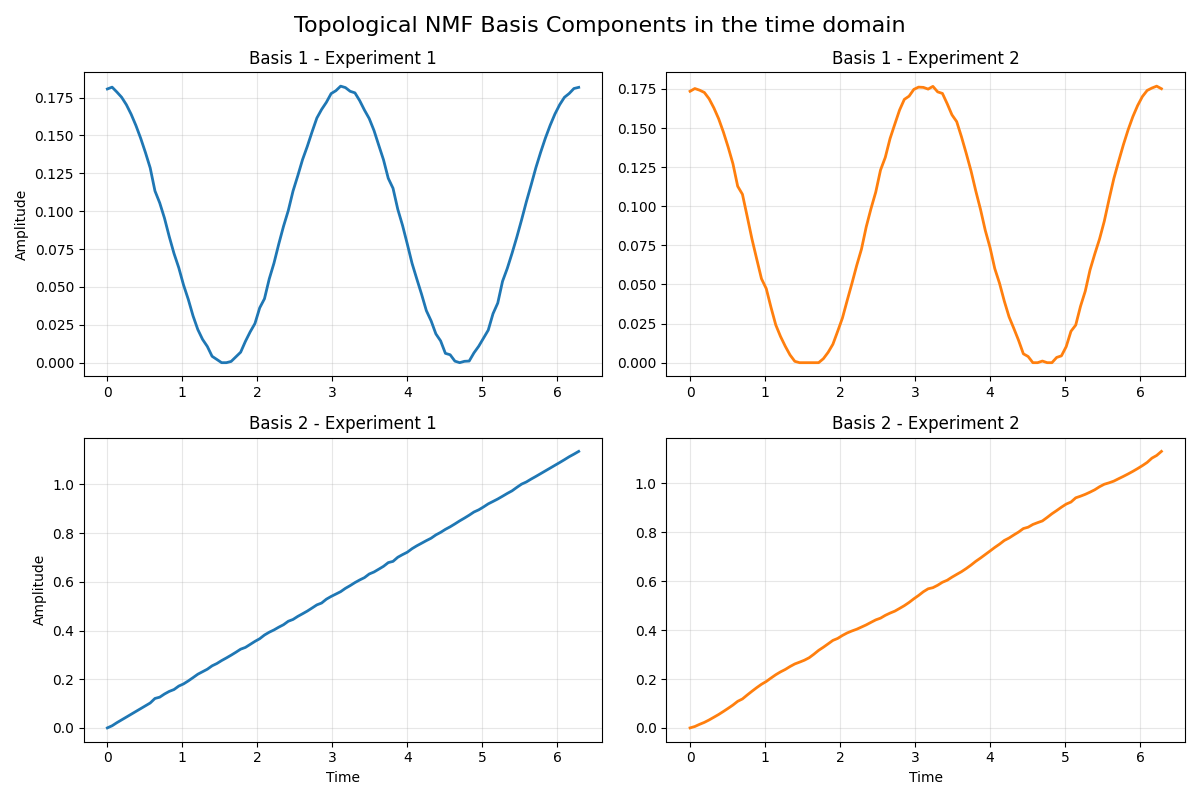

In [6]:
# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Set overall title
fig.suptitle("Topological NMF Basis Components in the time domain", fontsize=16)

# --- First Column: Experiment 1 (Cosine Data) ---
# Basis 1
axes[0, 0].plot(t, V1[0], linewidth=2, color='tab:blue')
axes[0, 0].set_title("Basis 1 - Experiment 1")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylabel("Amplitude")

# Basis 2
axes[1, 0].plot(t, V1[1], linewidth=2, color='tab:blue')
axes[1, 0].set_title("Basis 2 - Experiment 1")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].set_xlabel("Time")

# --- Second Column: Experiment 2 (Triangle Data) ---
# Basis 1
axes[0, 1].plot(t, V2[0], linewidth=2, color='tab:orange')
axes[0, 1].set_title("Basis 1 - Experiment 2")
axes[0, 1].grid(alpha=0.3)

# Basis 2
axes[1, 1].plot(t, V2[1], linewidth=2, color='tab:orange')
axes[1, 1].set_title("Basis 2 - Experiment 2")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlabel("Time")

plt.tight_layout()
plt.show()

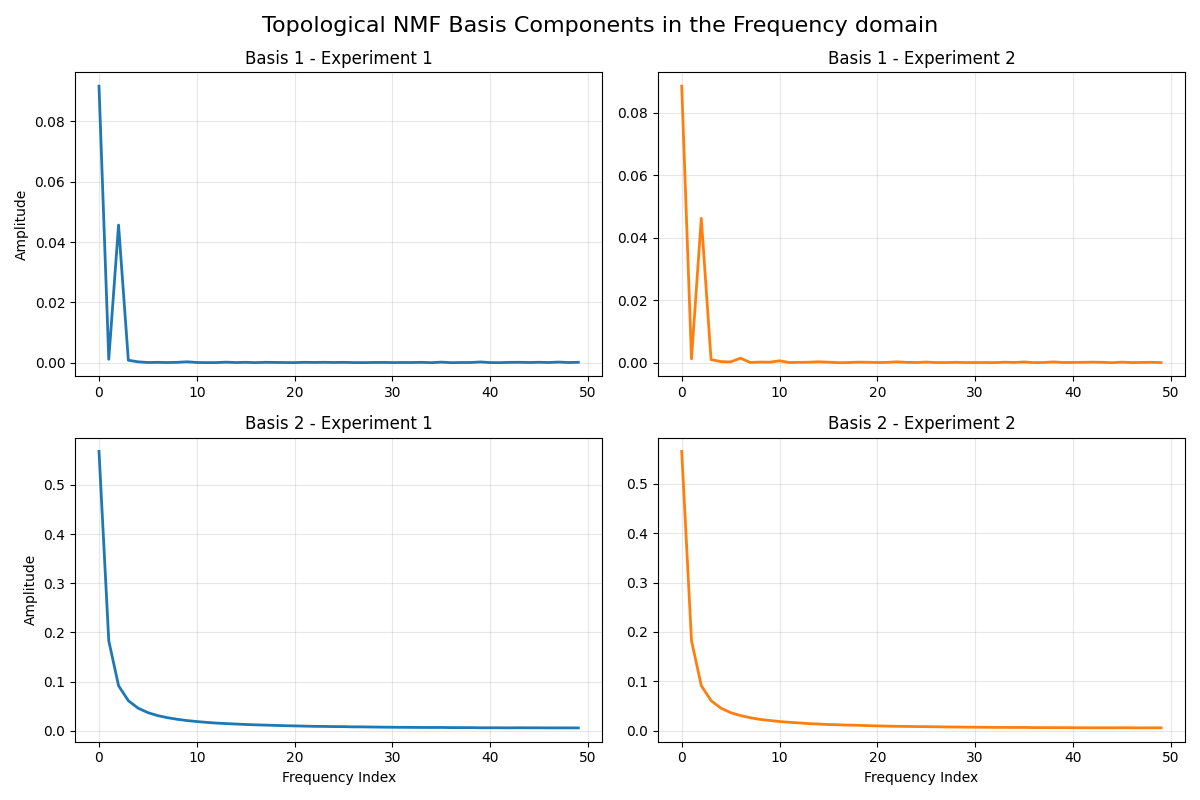

In [7]:
# frequency range to display (x-axis length)
n_freq_components = 50

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Set overall title
fig.suptitle("Topological NMF Basis Components in the Frequency domain", fontsize=16)

# --- First Column: Experiment 1 (V1) ---
# Basis 1
spec_v1_0 = np.abs(np.fft.fft(V1[0]))[:n_freq_components] / len(V1[0])
axes[0, 0].plot(spec_v1_0, linewidth=2, color='tab:blue')
axes[0, 0].set_title("Basis 1 - Experiment 1")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylabel("Amplitude")

# Basis 2
spec_v1_1 = np.abs(np.fft.fft(V1[1]))[:n_freq_components] / len(V1[1])
axes[1, 0].plot(spec_v1_1, linewidth=2, color='tab:blue')
axes[1, 0].set_title("Basis 2 - Experiment 1")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].set_xlabel("Frequency Index") # Time -> Frequency Index

# --- Second Column: Experiment 2 (V2) ---
# Basis 1
spec_v2_0 = np.abs(np.fft.fft(V2[0]))[:n_freq_components] / len(V2[0])
axes[0, 1].plot(spec_v2_0, linewidth=2, color='tab:orange')
axes[0, 1].set_title("Basis 1 - Experiment 2")
axes[0, 1].grid(alpha=0.3)

# Basis 2
spec_v2_1 = np.abs(np.fft.fft(V2[1]))[:n_freq_components] / len(V2[1])
axes[1, 1].plot(spec_v2_1, linewidth=2, color='tab:orange')
axes[1, 1].set_title("Basis 2 - Experiment 2")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlabel("Frequency Index") # Time -> Frequency Index

plt.tight_layout()
plt.show()

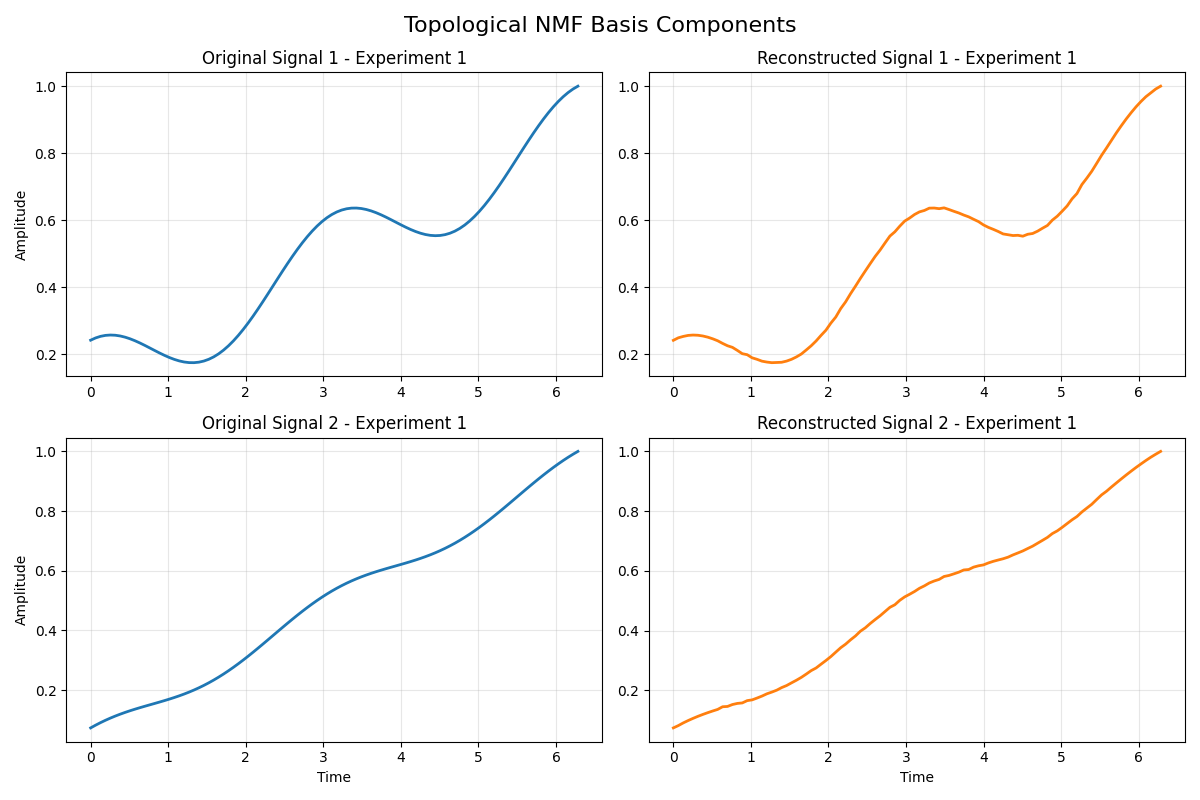

In [8]:
# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Set overall title
fig.suptitle("Topological NMF Basis Components", fontsize=16)

# --- First Column: Experiment 1 (Cosine Data) ---
# Basis 1
axes[0, 0].plot(t, X[0], linewidth=2, color='tab:blue')
axes[0, 0].set_title("Original Signal 1 - Experiment 1")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylabel("Amplitude")

# Basis 2
axes[1, 0].plot(t, X[1], linewidth=2, color='tab:blue')
axes[1, 0].set_title("Original Signal 2 - Experiment 1")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].set_xlabel("Time")

# --- Second Column: Experiment 2 (Triangle Data) ---
# Basis 1
axes[0, 1].plot(t, X_reconstructed_1[0], linewidth=2, color='tab:orange')
axes[0, 1].set_title("Reconstructed Signal 1 - Experiment 1")
axes[0, 1].grid(alpha=0.3)

# Basis 2
axes[1, 1].plot(t, X_reconstructed_1[1], linewidth=2, color='tab:orange')
axes[1, 1].set_title("Reconstructed Signal 2 - Experiment 1")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlabel("Time")

plt.tight_layout()
plt.show()